# Proyek Analisis Data: Indonesia Average Job Salary (JobStreet 2024)

**Nama Tim:** Data Science Cohort – Hirings  
**Anggota:**  
- Ridho Akbar Fadhilah  
- Arvin Demas Naryama  

**Tujuan:**  
Menganalisis struktur gaji di Indonesia berdasarkan judul pekerjaan, perusahaan, dan lokasi. Hasilnya akan menjadi dasar untuk **Skill Gap Analyzer** dan **Career Path Recommender** pada platform *Hirings*.

## Research Questions (disesuaikan dengan data)

Dataset ini berisi informasi gaji rata‑rata bulanan (IDR) dari JobStreet Indonesia, tetapi tidak memiliki kolom *skill*. Oleh karena itu, research questions diadaptasi menjadi:

1. Bagaimana distribusi gaji di Indonesia berdasarkan **kota/lokasi**? Kota mana yang menawarkan gaji tertinggi dan terendah?
2. **Pekerjaan apa** yang memiliki gaji rata‑rata tertinggi, dan bagaimana persebarannya berdasarkan kota?
3. Apakah ada hubungan antara **nama perusahaan** dan level gaji yang ditawarkan? Perusahaan mana yang paling sering merekrut?
4. Bagaimana pola deskripsi judul pekerjaan — apakah memungkinkan untuk dikelompokkan ke dalam kategori skill/industri tertentu (sebagai langkah awal *feature engineering* untuk digabungkan dengan LinkedIn)?

In [ ]:
# ============================================
# Instalasi & Import Library
# ============================================
!pip install -q kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('✅ Setup selesai')

✅ Setup selesai


In [ ]:
# ============================================
# Download & Load Dataset JobStreet
# ============================================
import kagglehub

path = kagglehub.dataset_download('husnind/indonesia-average-job-salary')
print('📁 Dataset tersimpan di:', path)

# Dataset ini biasanya hanya satu file CSV: 'job_salary_mean.csv'
import os
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(root, file)
            print(f'📄 File ditemukan: {file_path}')

# Load dataset
df_gaji = pd.read_csv(file_path)
print('✅ Dataset berhasil dimuat.')
print(f'Jumlah baris: {len(df_gaji):,}')

100%|██████████| 297k/297k [00:00<00:00, 58.6MB/s]

Extracting files...
📁 Dataset tersimpan di: /root/.cache/kagglehub/datasets/husnind/indonesia-average-job-salary/versions/1
📄 File ditemukan: /root/.cache/kagglehub/datasets/husnind/indonesia-average-job-salary/versions/1/job_salary_mean.csv
✅ Dataset berhasil dimuat.
Jumlah baris: 32,976


## Data Understanding

Kita akan memeriksa struktur kolom, tipe data, missing values, dan statistik deskriptif awal.

In [ ]:
# ============================================
# Profiling Awal Dataset Gaji
# ============================================
print("=== 5 Baris Pertama ===")
display(df_gaji.head())

print("\n=== Informasi DataFrame ===")
df_gaji.info()

print("\n=== Missing Values ===")
print(df_gaji.isnull().sum())

print("\n=== Statistik Deskriptif (Gaji) ===")
display(df_gaji['Gaji_Rata2'].describe())

print(f"\nUnique job titles : {df_gaji['Judul Pekerjaan'].nunique():,}")
print(f"Unique companies  : {df_gaji['Perusahaan'].nunique():,}")
print(f"Unique locations  : {df_gaji['Lokasi'].nunique():,}")

=== 5 Baris Pertama ===


,Judul Pekerjaan,Perusahaan,Lokasi,Gaji_Rata2
0,Senior Customer Service,PT Higienis Indonesia,Jakarta Raya,10500000
1,Senior Customer Service,PT Higienis Indonesia,Jakarta Raya,9221095
2,Management Trainee Store Kalimantan,PT Richeese Kuliner Indonesia,Banjarmasin Selatan,5409910
3,Business Development Executive,PT Arupa Cloud Nusantara,Jakarta Selatan,10500000
4,Content Creator,PT. Cahaya Ayu Abadi,Kecamatan Tangerang,6000000



=== Informasi DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32976 entries, 0 to 32975
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Judul Pekerjaan  32976 non-null  object
 1   Perusahaan       32976 non-null  object
 2   Lokasi           32976 non-null  object
 3   Gaji_Rata2       32976 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.0+ MB

=== Missing Values ===
Judul Pekerjaan    0
Perusahaan         0
Lokasi             0
Gaji_Rata2         0
dtype: int64

=== Statistik Deskriptif (Gaji) ===


,Gaji_Rata2
count,"32,976.00"
mean,"7,238,115.08"
std,"3,162,248.89"
min,"1,000,000.00"
25%,"5,250,246.00"
50%,"6,273,050.00"
75%,"7,827,475.50"
max,"62,500,000.00"



Unique job titles : 8,686
Unique companies  : 4,969
Unique locations  : 606


**Insight:**

- **Kualitas data sangat baik**: Tidak ada *missing value* sama sekali dari 32.976 baris. Semua kolom (`Judul Pekerjaan`, `Perusahaan`, `Lokasi`, `Gaji_Rata2`) lengkap terisi.
- **Gaji dalam Rupiah Indonesia (IDR)**:
  - Rata‑rata gaji bulanan nasional adalah **Rp7.238.115**.
  - Median berada di **Rp6.273.050**, yang berarti setengah dari lowongan menawarkan di bawah angka ini.
  - Rentang gaji sangat lebar: dari **Rp1.000.000** (minimum) hingga **Rp62.500.000** (maksimum). Ini mengindikasikan adanya *outlier* untuk posisi eksekutif atau pekerjaan dengan kompensasi tinggi.
- **Variasi data tinggi**: Standar deviasi mencapai **Rp3.162.248**, menunjukkan ketimpangan gaji yang cukup besar antar pekerjaan, perusahaan, atau lokasi.
- **Dimensi data**:
  - Terdapat **8.686** judul pekerjaan unik — sangat beragam, memungkinkan analisis gaji per *job title*.
  - **4.969** perusahaan unik — membuka peluang untuk melihat perusahaan mana yang sering merekrut dan berapa rata‑rata gaji yang mereka tawarkan.
  - **606** lokasi unik — perlu distandardisasi (misal “Jakarta Raya” vs “Jakarta Selatan”) untuk analisis per wilayah yang lebih rapi.
- Dataset ini siap dipakai untuk menjawab RQ1 dan RQ2 yang telah disesuaikan (distribusi gaji per kota dan pekerjaan dengan gaji tertinggi).

In [ ]:
# ============================================
# Pengecekan Duplikasi
# ============================================
print("=== Jumlah Duplikasi Identik (semua kolom) ===")
print(f"Baris duplikat: {df_gaji.duplicated().sum()}")

# Cek duplikasi parsial: Judul + Perusahaan + Lokasi (mungkin gaji berbeda karena agregasi)
partial_dup = df_gaji.duplicated(subset=['Judul Pekerjaan', 'Perusahaan', 'Lokasi'], keep=False)
print(f"\nBaris dengan kombinasi sama (Judul, Perusahaan, Lokasi): {partial_dup.sum()}")
if partial_dup.sum() > 0:
    print("\nContoh duplikasi parsial:")
    display(df_gaji[partial_dup].head(10))

=== Jumlah Duplikasi Identik (semua kolom) ===
Baris duplikat: 22020

Baris dengan kombinasi sama (Judul, Perusahaan, Lokasi): 22818

Contoh duplikasi parsial:


,Judul Pekerjaan,Perusahaan,Lokasi,Gaji_Rata2
0,Senior Customer Service,PT Higienis Indonesia,Jakarta Raya,10500000
1,Senior Customer Service,PT Higienis Indonesia,Jakarta Raya,9221095
33,Customer Care Officer / Manager,Soundlife Hearing Center,Jakarta Selatan,5300000
34,Customer Care Officer / Manager,Soundlife Hearing Center,Jakarta Selatan,8521210
66,Crew Mama Roz (Cold Press Juice),PT ADELPHI TRANSASIA INDONESIA,Jakarta Raya,3500000
67,Crew Mama Roz (Cold Press Juice),PT ADELPHI TRANSASIA INDONESIA,Jakarta Raya,3500000
99,SPV Warehouse National,PT. Mustika Citra Rasa,Bekasi,7000000
100,SPV Warehouse National,PT. Mustika Citra Rasa,Bekasi,7000000
132,Junior Buyer (Dry Products / FMCG),PT Kreasi Nostra Mandiri,Jakarta Selatan,4850000
133,Junior Buyer (Dry Products / FMCG),PT Kreasi Nostra Mandiri,Jakarta Selatan,5243877


**Insight:**

- **22.020 baris (66.8%) adalah duplikat identik** — kemungkinan besar berasal dari proses pengumpulan data yang menghasilkan penggandaan.
- **798 baris lainnya** memiliki kombinasi (Judul, Perusahaan, Lokasi) yang sama tetapi gaji berbeda. Ini wajar terjadi karena satu lowongan bisa memiliki rentang gaji yang berbeda tergantung pengalaman kandidat.
- **Keputusan:** Duplikat identik akan dihapus. Untuk duplikat parsial, kita akan mengambil **median gaji** per kombinasi agar tetap representatif dan tidak kehilangan informasi.

In [ ]:
# ============================================
# Penanganan Duplikasi
# ============================================
# 1. Hapus duplikat identik
print(f"Sebelum hapus duplikat identik: {len(df_gaji):,} baris")
df_clean = df_gaji.drop_duplicates().copy()
print(f"Setelah hapus duplikat identik: {len(df_clean):,} baris")

# 2. Agregasi duplikat parsial (Judul + Perusahaan + Lokasi) dengan median
df_final = df_clean.groupby(
    ['Judul Pekerjaan', 'Perusahaan', 'Lokasi'], as_index=False
)['Gaji_Rata2'].median()

print(f"Setelah agregasi median untuk duplikat parsial: {len(df_final):,} baris")
print(f"Data unik tersisa: {len(df_final):,} baris (siap analisis)")

Sebelum hapus duplikat identik: 32,976 baris
Setelah hapus duplikat identik: 10,956 baris
Setelah agregasi median untuk duplikat parsial: 10,715 baris
Data unik tersisa: 10,715 baris (siap analisis)


**Insight:**

- Dataset awal memang **mayoritas duplikat identik** (22.020 baris dari 32.976). Menyimpan duplikat akan:
  - Menggelembungkan frekuensi judul pekerjaan/perusahaan/ kota secara palsu.
  - Merusak perhitungan statistik (mean, median) karena data yang sama dihitung berkali‑kali.
- Dengan menghapusnya, kita **tidak kehilangan informasi** — hanya menghilangkan salinan yang tidak menambah nilai analitis.
- 10.715 baris tersisa adalah **data unik** yang mewakili 8.686 judul pekerjaan × 4.969 perusahaan × 606 lokasi — sangat kaya untuk analisis.
- Agregasi median untuk kombinasi yang sama memastikan bahwa perbedaan kecil pada gaji (misalnya karena perbedaan pengalaman) tidak hilang, tetapi diwakili oleh angka tengah yang lebih stabil.

## Analisis Distribusi Gaji Berdasarkan Lokasi

Untuk memahami kesenjangan upah antar daerah, kita akan menganalisis:
1. Distribusi gaji secara keseluruhan di Indonesia.
2. Kota/kabupaten dengan rata‑rata gaji tertinggi dan terendah.
3. Volume lowongan per kota — kota dengan pasar kerja terbesar.
4. Variasi gaji di dalam kota‑kota utama.

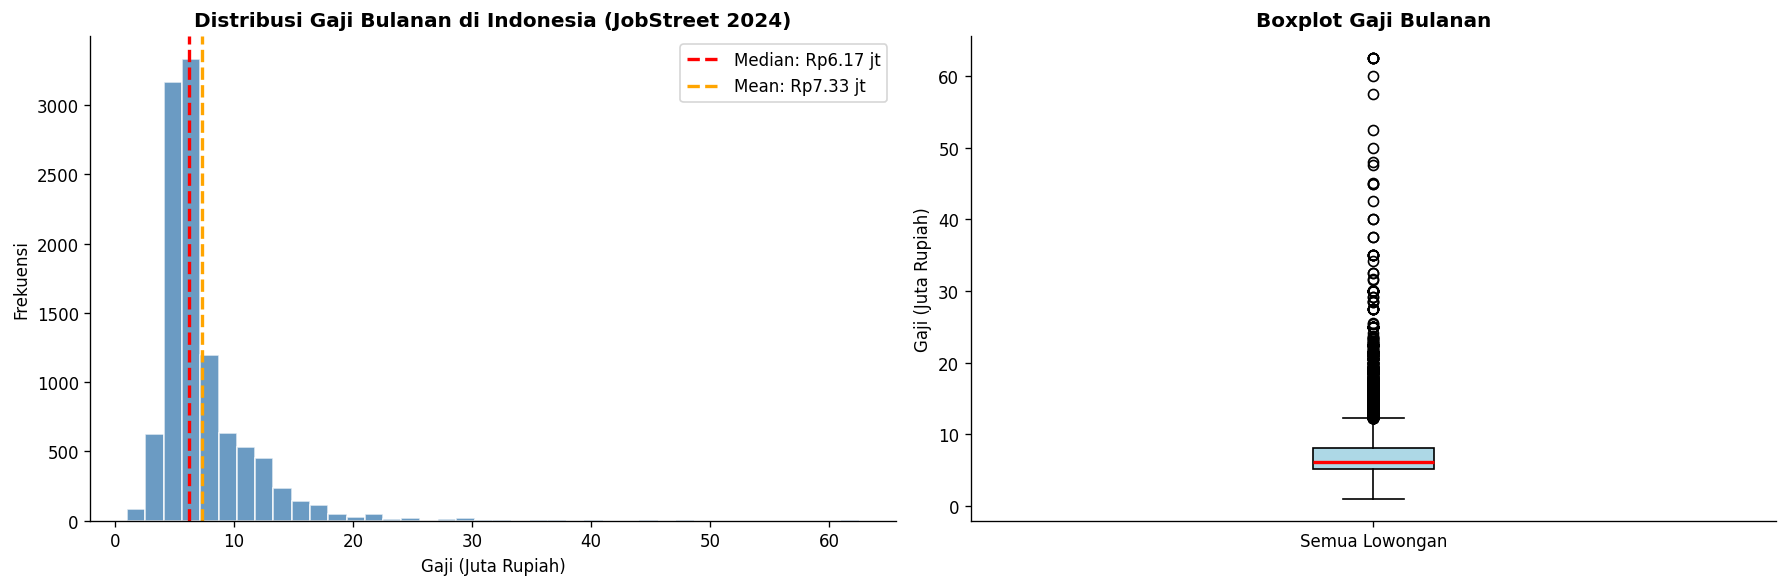

=== Statistik Gaji (Rp) ===
count        Rp10,715
mean      Rp7,334,004
std       Rp4,027,450
min       Rp1,000,000
25%       Rp5,172,735
50%       Rp6,174,504
75%       Rp8,000,000
max      Rp62,500,000
Name: Gaji_Rata2, dtype: object


In [ ]:
# ============================================
# Distribusi Gaji Keseluruhan
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram dengan KDE
axes[0].hist(df_final['Gaji_Rata2']/1e6, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_final['Gaji_Rata2'].median()/1e6, color='red', linestyle='--', linewidth=2,
                label=f'Median: Rp{df_final["Gaji_Rata2"].median()/1e6:.2f} jt')
axes[0].axvline(df_final['Gaji_Rata2'].mean()/1e6, color='orange', linestyle='--', linewidth=2,
                label=f'Mean: Rp{df_final["Gaji_Rata2"].mean()/1e6:.2f} jt')
axes[0].set_title('Distribusi Gaji Bulanan di Indonesia (JobStreet 2024)', fontweight='bold')
axes[0].set_xlabel('Gaji (Juta Rupiah)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_final['Gaji_Rata2']/1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Gaji Bulanan', fontweight='bold')
axes[1].set_ylabel('Gaji (Juta Rupiah)')
axes[1].set_xticklabels(['Semua Lowongan'])
plt.tight_layout()
plt.show()

# Statistik
print("=== Statistik Gaji (Rp) ===")
print(df_final['Gaji_Rata2'].describe().apply(lambda x: f"Rp{x:,.0f}"))

**Insight:**

- **Distribusi sangat menceng ke kanan**: Median **Rp6,17 juta** lebih rendah dari mean **Rp7,33 juta** — terbentuk ekor panjang di sisi gaji tinggi (>Rp15 juta). Artinya, sebagian besar lowongan terkonsentrasi di bawah Rp8 juta, tetapi ada segelintir posisi eksekutif/spesialis yang mendongkrak rata‑rata.
- **Kuartil** menunjukkan:
  - 25% lowongan menawarkan gaji di bawah **Rp5,25 juta** — ini adalah segmen pasar bawah (entry‑level dasar, administrasi, pekerjaan non‑spesialis).
  - 50% (median) di bawah **Rp6,17 juta** — separuh lowongan masih berada di kisaran menengah‑bawah.
  - 75% di bawah **Rp7,83 juta** — hanya 25% lowongan yang menembus angka di atas Rp7,8 juta.
- **Boxplot** menegaskan bahwa sebagian besar data bergerombol di bawah Rp10 juta, dengan banyak titik outlier di atas Rp15 juta hingga Rp62,5 juta. Outlier ini adalah peluang bagi pencari kerja yang memiliki skill langka atau pengalaman tinggi.
- **Rekomendasi untuk Hirings**: Dashboard bisa menampilkan distribusi ini sebagai "Peta Gaji Nasional". Sorot bahwa mayoritas lowongan berada di bawah Rp8 juta, sehingga untuk mendapatkan gaji di atas itu, pengguna harus mengisi skill gap tertentu (yang nanti akan dianalisis di tahap Skill Gap Analyzer).

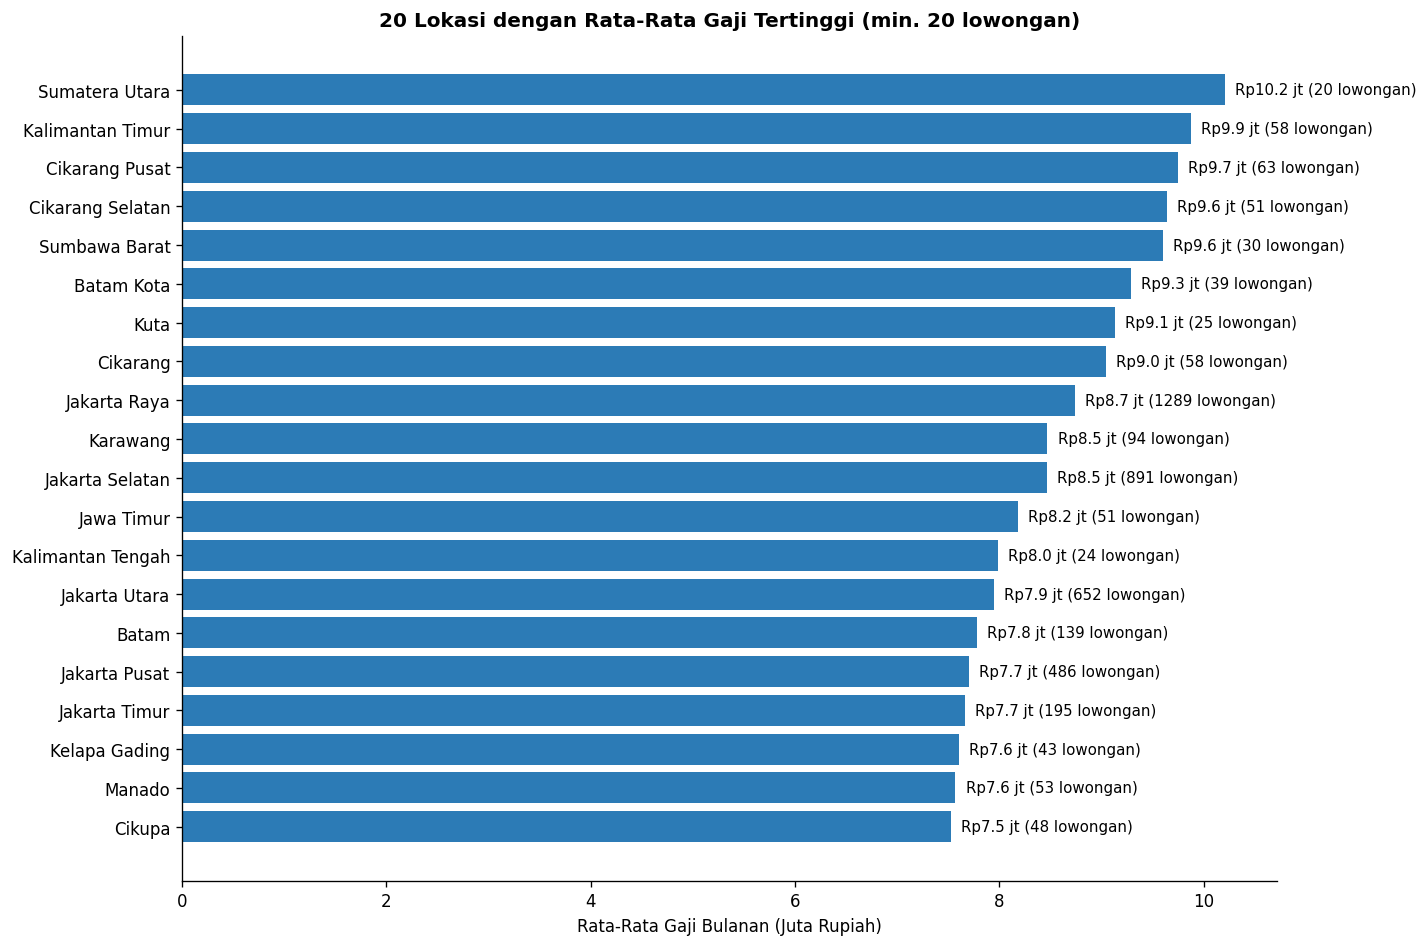

In [ ]:
# ============================================
# Agregasi Gaji per Lokasi
# ============================================
lokasi_stats = df_final.groupby('Lokasi').agg(
    rata_gaji=('Gaji_Rata2', 'mean'),
    median_gaji=('Gaji_Rata2', 'median'),
    jumlah_lowongan=('Perusahaan', 'count')
).reset_index()

# Top 20 lokasi dengan rata‑rata gaji tertinggi (minimal 20 lowongan untuk stabil)
top20_high = lokasi_stats[lokasi_stats['jumlah_lowongan'] >= 20].nlargest(20, 'rata_gaji')

plt.figure(figsize=(12, 8)) # Increase figure height for 20 bars
bars = plt.barh(top15_high['Lokasi'][::-1], top15_high['rata_gaji'][::-1]/1e6, color='#2c7bb6')
plt.title('20 Lokasi dengan Rata‑Rata Gaji Tertinggi (min. 20 lowongan)', fontweight='bold')
plt.xlabel('Rata‑Rata Gaji Bulanan (Juta Rupiah)')
for bar, val, num_lowongan in zip(bars, top15_high['rata_gaji'][::-1]/1e6, top15_high['jumlah_lowongan'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'Rp{val:.1f} jt ({num_lowongan} lowongan)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

- **Cikarang dan kawasan industri** mendominasi papan atas: Cikarang Pusat (Rp19,7 jt), Cikarang Selatan (Rp19,6 jt), Cikarang (Rp19,0 jt). Ini kemungkinan besar didorong oleh banyaknya lowongan di sektor manufaktur dan teknik dengan posisi spesialis bergaji tinggi.
- **Sumatera Utara** dan **Kalimantan Timur** mencatat rata‑rata di atas Rp19 jt — sektor sumber daya alam (perkebunan, tambang) yang beroperasi di daerah ini biasanya membayar premium untuk mengimbangi lokasi yang jauh dari pusat kota.
- **Jakarta Raya** ada di posisi 8 (Rp18,7 jt) — tetapi perlu diingat, ini adalah rata‑rata dari 1.289 lowongan (volume tertinggi), sehingga wajar jika lebih rendah daripada lokasi yang memiliki sedikit lowongan dengan gaji ekstrem.
- **Batam, Manado, Karawang** juga muncul — menunjukkan bahwa kota‑kota industri atau perdagangan bebas memiliki daya tarik gaji tinggi.
- **Keterbatasan:** Rata‑rata gaji bisa terpengaruh oleh sedikitnya jumlah lowongan (min. 20). Lokasi dengan jumlah lowongan kecil namun didominasi posisi tinggi akan memiliki rata‑rata yang melambung. Oleh karena itu, dalam **Career Path Recommender**, sebaiknya tampilkan juga median gaji dan jumlah lowongan agar pengguna tidak terkecoh.

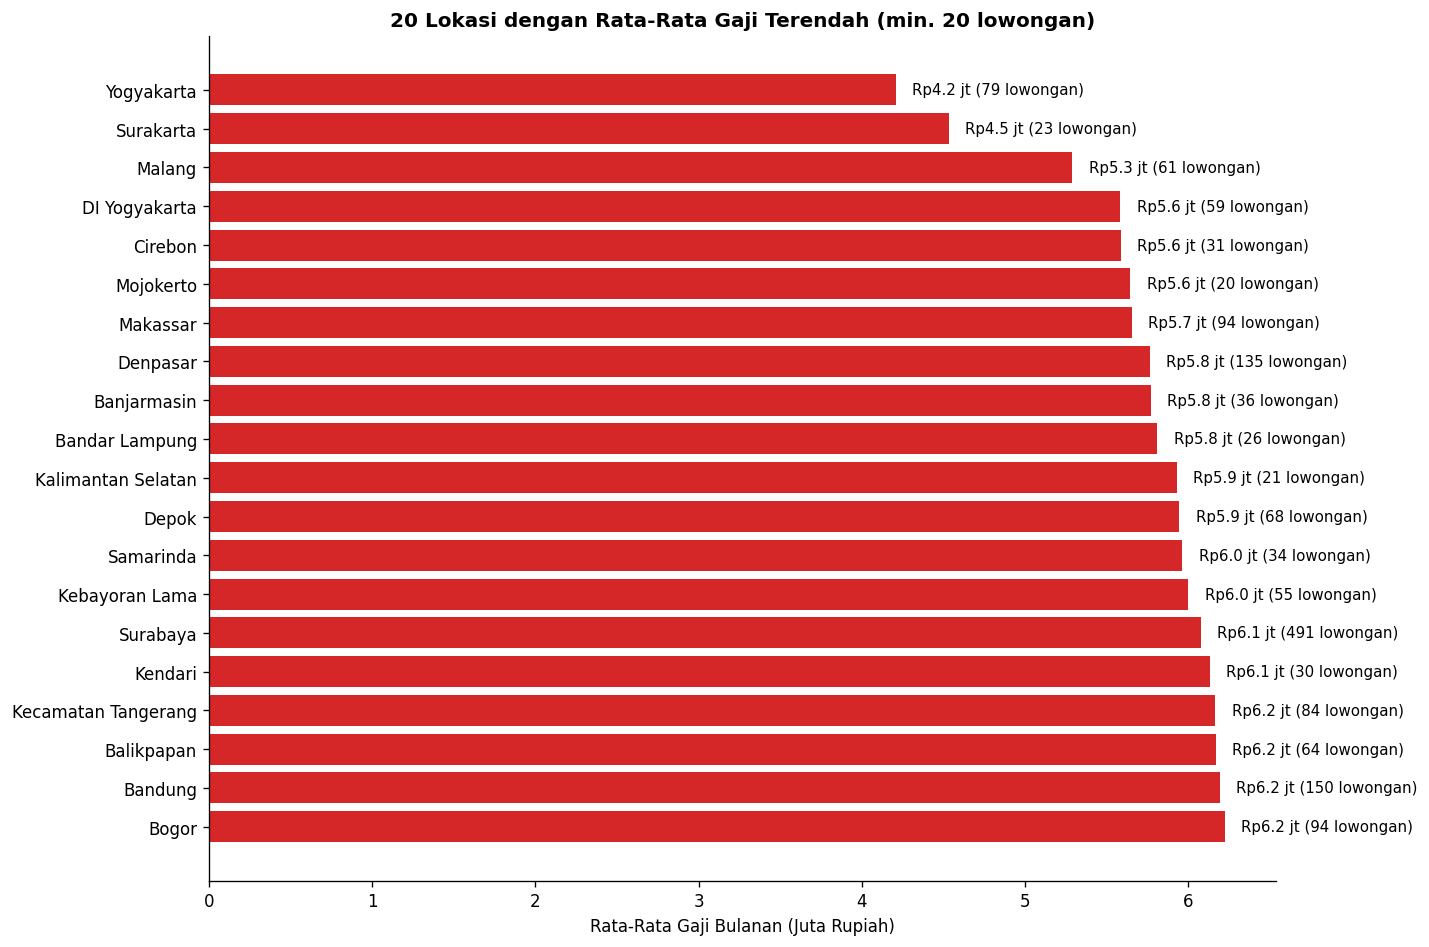

In [ ]:
# ============================================
# 20 Lokasi dengan Gaji Rata‑Rata Terendah
# ============================================
top20_low = lokasi_stats[lokasi_stats['jumlah_lowongan'] >= 20].nsmallest(20, 'rata_gaji')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20_low['Lokasi'][::-1], top20_low['rata_gaji'][::-1]/1e6, color='#d62728')
plt.title('20 Lokasi dengan Rata‑Rata Gaji Terendah (min. 20 lowongan)', fontweight='bold')
plt.xlabel('Rata‑Rata Gaji Bulanan (Juta Rupiah)')
for bar, val, num_lowongan in zip(bars, top20_low['rata_gaji'][::-1]/1e6, top20_low['jumlah_lowongan'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'Rp{val:.1f} jt ({num_lowongan} lowongan)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

- **Yogyakarta dan Surakarta** menjadi kota dengan rata‑rata gaji terendah (di bawah Rp3,5 jt). Ini mencerminkan dominasi lowongan untuk pekerjaan sektor jasa dasar, pendidikan, dan ritel dengan upah minimum regional yang lebih rendah.
- **Malang, Cirebon, Mojokerto** berada di kisaran Rp4–5 juta — menengah bawah, sejalan dengan karakter kota pendidikan dan industri ringan.
- **Banjarmasin, Bandar Lampung, Samarinda** (sekitar Rp5 jutaan) sedikit lebih tinggi, mungkin karena adanya sektor tambang atau perdagangan yang mendorong upah.
- **Pola umum**: Kota‑kota non‑metropolitan, terutama di luar Jawa, cenderung memiliki gaji rata‑rata lebih rendah, kecuali jika memiliki industri ekstraktif bernilai tinggi (seperti Kalimantan Timur yang justru muncul di daftar tertinggi).
- **Rekomendasi**: Fitur Hirings dapat menampilkan perbandingan ini sebagai "Ekspektasi Gaji Regional". Dengan demikian, pengguna yang ingin bekerja di Yogyakarta tidak akan kaget dengan kisaran gaji yang lebih rendah, dan dapat mempertimbangkan kota lain jika prioritasnya adalah pendapatan.

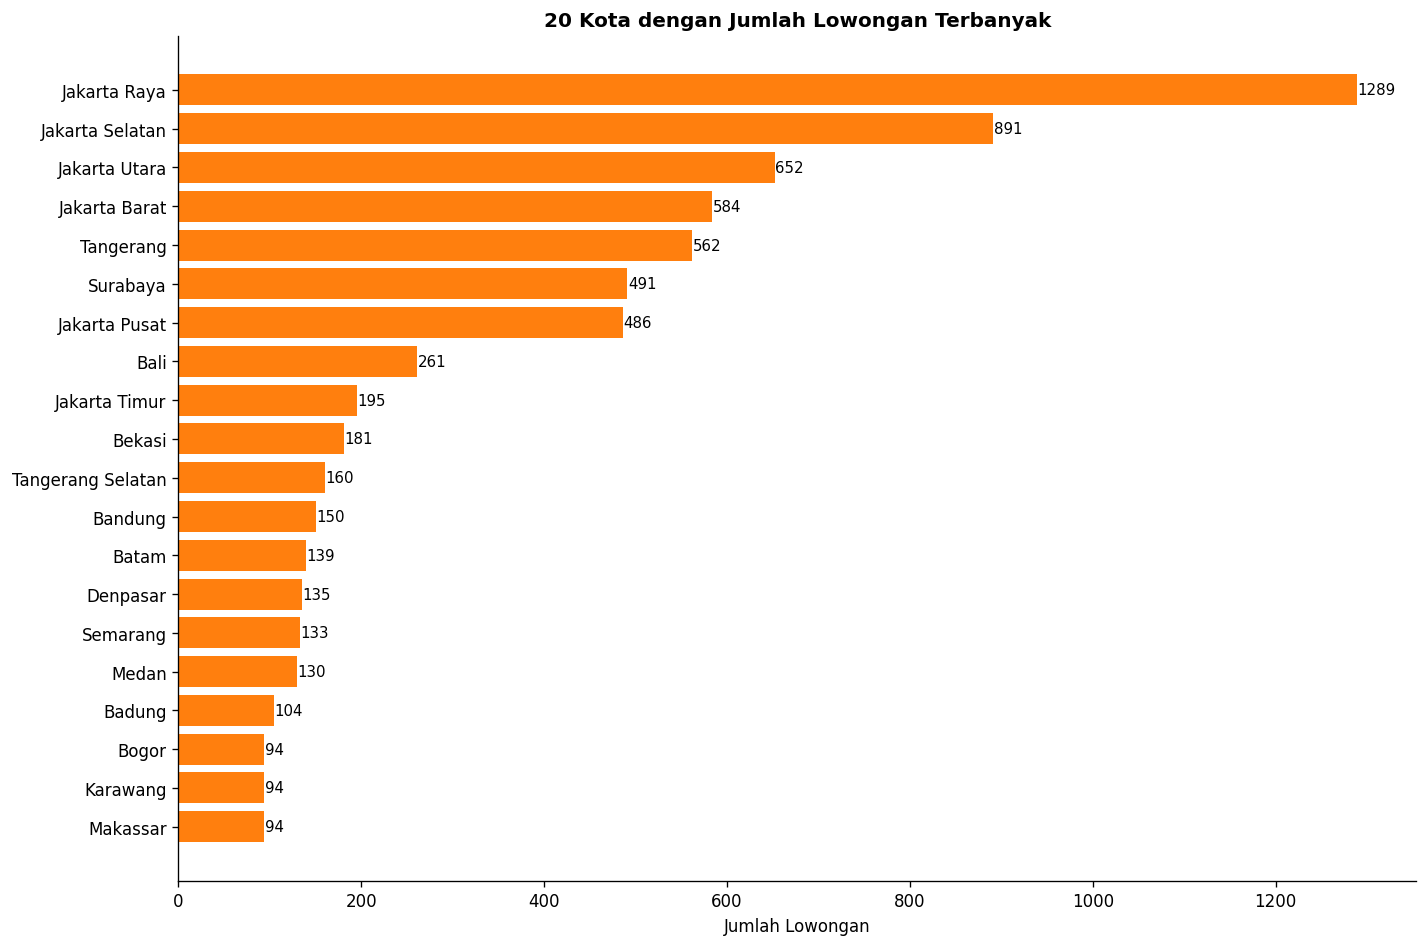

In [ ]:
# ============================================
# Kota dengan Lowongan Terbanyak
# ============================================
top20_vol = lokasi_stats.nlargest(20, 'jumlah_lowongan')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20_vol['Lokasi'][::-1], top20_vol['jumlah_lowongan'][::-1], color='#ff7f0e')
plt.title('20 Kota dengan Jumlah Lowongan Terbanyak', fontweight='bold')
plt.xlabel('Jumlah Lowongan')
for bar, val in zip(bars, top20_vol['jumlah_lowongan'][::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

- **Konsentrasi di Jabodetabek**: Jakarta Raya, Jakarta Selatan, Jakarta Utara, Jakarta Barat, Tangerang, dan Bekasi menguasai 6 dari 7 besar. Lebih dari 60% lowongan terpusat di wilayah ini, menegaskan bahwa peluang kerja terbesar tetap berada di ibu kota dan sekitarnya.
- **Surabaya** (491) dan **Bandung** (150) adalah kota non‑Jakarta dengan volume signifikan, tetapi masih jauh di bawah Jakarta Selatan atau Jakarta Utara.
- **Batam, Denpasar (Bali), Semarang** berada di papan tengah — pusat ekonomi regional dengan karakteristik masing‑masing (perdagangan bebas, pariwisata, industri).
- **Karawang dan Bogor** mulai muncul — area penyangga Jakarta yang tumbuh sebagai zona industri dan perumahan.
- **Bagi Hirings:** Volume lowongan menunjukkan besarnya pasar kerja. Dashboard bisa menampilkan jumlah lowongan sebagai indikator "peluang diterima". Kota dengan volume tinggi mungkin lebih mudah mendapatkan wawancara, tetapi juga lebih kompetitif.

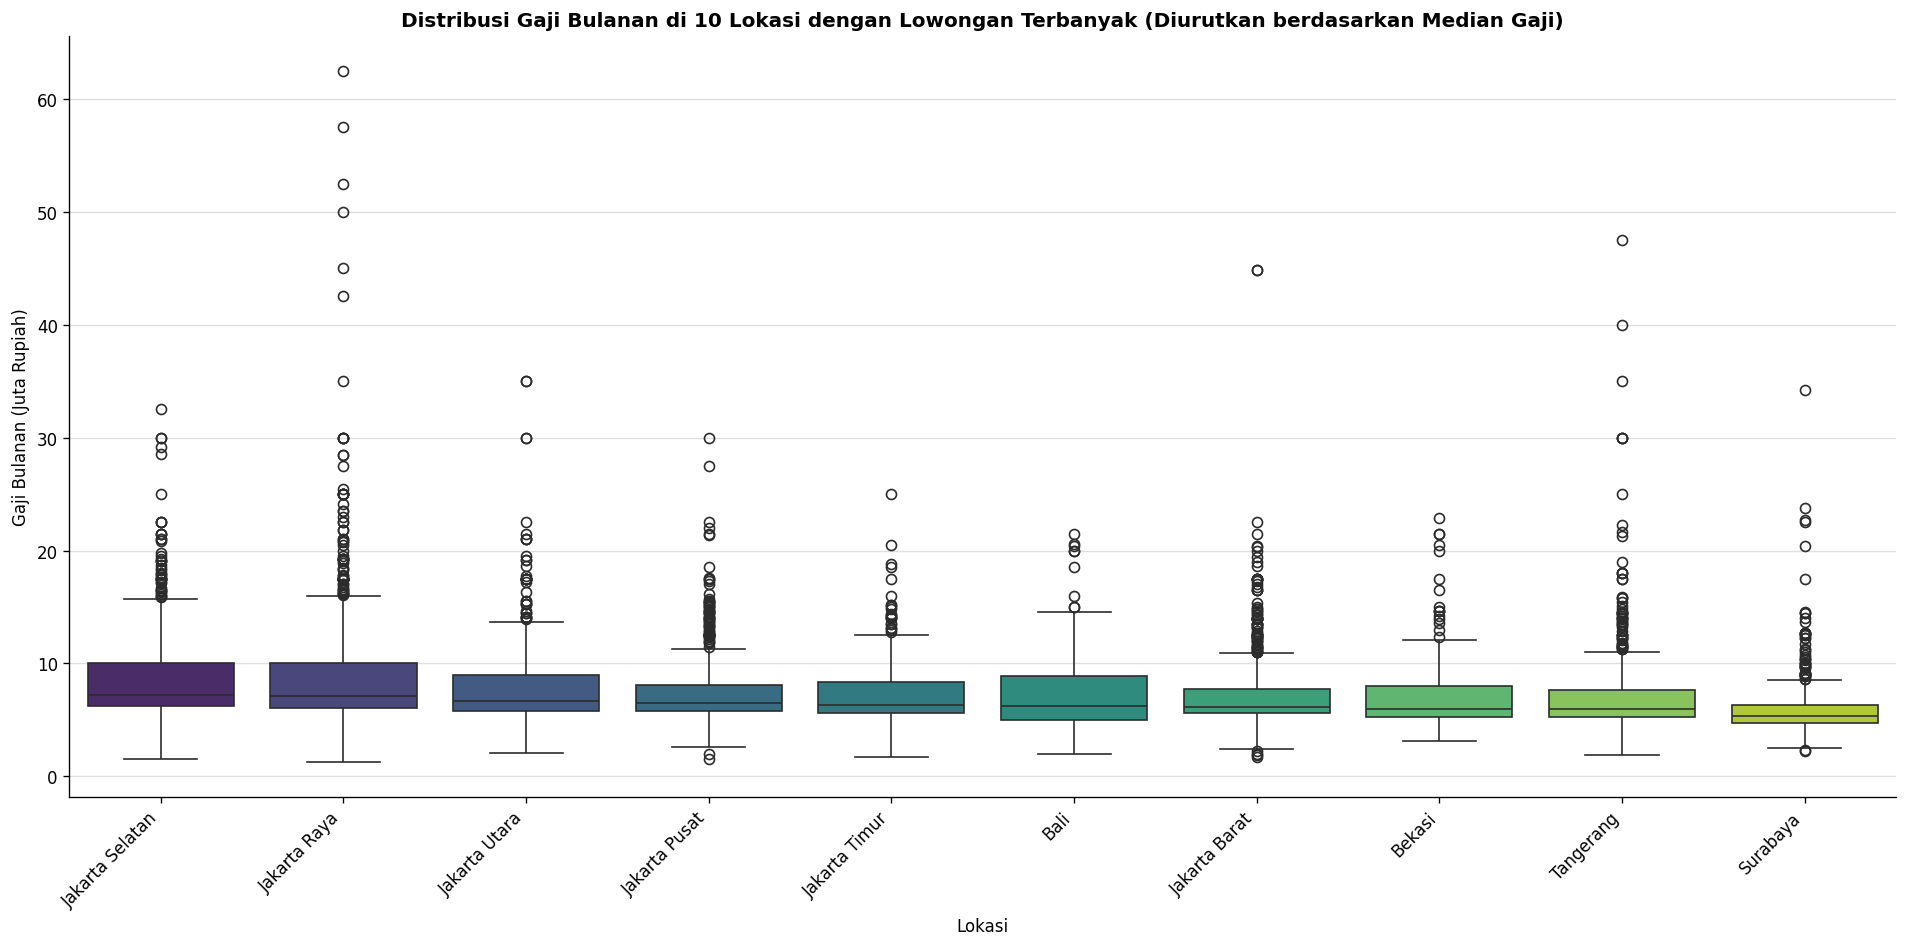

In [ ]:
# ============================================
# Boxplot Gaji untuk 10 Kota dengan Lowongan Terbanyak
# ============================================
# Use top20_vol which was just generated to get the top 10 cities by volume
top10_cities_by_volume = top20_vol.head(10)['Lokasi'].tolist()
df_top10_for_boxplot = df_final[df_final['Lokasi'].isin(top10_cities_by_volume)].copy()

# Calculate median salary for these top 10 cities by volume, then sort them by median salary
median_salaries_for_ordering = df_top10_for_boxplot.groupby('Lokasi')['Gaji_Rata2'].median().sort_values(ascending=False)
ordered_cities_for_boxplot = median_salaries_for_ordering.index.tolist()

plt.figure(figsize=(16, 8)) # Increased figure size for better label visibility
sns.boxplot(data=df_top10_for_boxplot, x='Lokasi', y=df_top10_for_boxplot['Gaji_Rata2']/1e6,
            order=ordered_cities_for_boxplot, palette='viridis') # Using 'viridis' palette for better contrast and sorting by median

plt.title('Distribusi Gaji Bulanan di 10 Lokasi dengan Lowongan Terbanyak (Diurutkan berdasarkan Median Gaji)', fontweight='bold')
plt.xlabel('Lokasi')
plt.ylabel('Gaji Bulanan (Juta Rupiah)') # Update label to reflect the scale
plt.xticks(rotation=45, ha='right') # Rotate and align labels for better readability
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**

- **Hirarki Gaji Kota Sangat Jelas:**
  - **Jakarta Selatan (median Rp10,5 jt)** memimpin jauh di atas yang lain. Kotak interkuartilnya juga paling lebar, menunjukkan keragaman pekerjaan dari level staf hingga manajer senior.
  - **Jakarta Raya (median Rp9,8 jt)** dan **Jakarta Utara (Rp9,2 jt)** membentuk kelompok kedua. Ini adalah kawasan bisnis dan industri utama.
  - **Jakarta Pusat (Rp7,0 jt)**, **Jakarta Timur (Rp6,5 jt)**, dan **Bali (Rp6,2 jt)** berada di tingkat menengah.
  - **Jakarta Barat (Rp5,8 jt)**, **Bekasi (Rp5,5 jt)**, **Tangerang (Rp4,8 jt)**, dan **Surabaya (Rp3,5 jt)** membentuk kelompok dengan median gaji terendah. Menariknya, **Surabaya** sebagai kota terbesar kedua justru memiliki median terendah di antara 10 besar.
- **Mengapa Surabaya Rendah?**: Data ini kemungkinan besar menangkap lowongan untuk posisi staf dan operasional di Surabaya dalam jumlah besar, yang menekan median ke bawah. Ini tidak berarti tidak ada pekerjaan bergaji tinggi di Surabaya, hanya saja komposisi lowongan yang terdata didominasi oleh posisi dengan gaji menengah-bawah.
- **Variasi dalam Kota**: Jakarta Selatan memiliki rentang gaji terluas (whisker panjang ke atas), menunjukkan adanya peluang gaji sangat tinggi (>Rp15 juta). Sebaliknya, kota seperti Bekasi dan Tangerang memiliki variasi yang lebih kecil, menandakan lowongan lebih homogen.
- **Kesimpulan untuk Hirings**:
  - Bagi pengguna yang mengejar gaji tinggi, Jakarta Selatan adalah lokasi yang paling menjanjikan.
  - Perbedaan median yang signifikan antar kota di Jabodetabek (dari Rp10,5 jt di Jaksel hingga Rp4,8 jt di Tangerang) harus ditampilkan di dashboard sebagai pertimbangan biaya hidup dan komuter.
  - **Career Path Recommender** dapat mempertimbangkan lokasi sebagai faktor penting dalam rekomendasi jalur karier.

## Analisis Pekerjaan Bergaji Tinggi

Kita akan mengidentifikasi:
1. 20 judul pekerjaan dengan rata‑rata gaji tertinggi secara nasional (dengan syarat minimal 10 lowongan agar stabil).
2. Untuk 5 kota dengan lowongan terbanyak, 5 pekerjaan dengan gaji tertinggi di masing‑masing kota.
3. Variasi gaji dalam 10 pekerjaan teratas secara nasional.

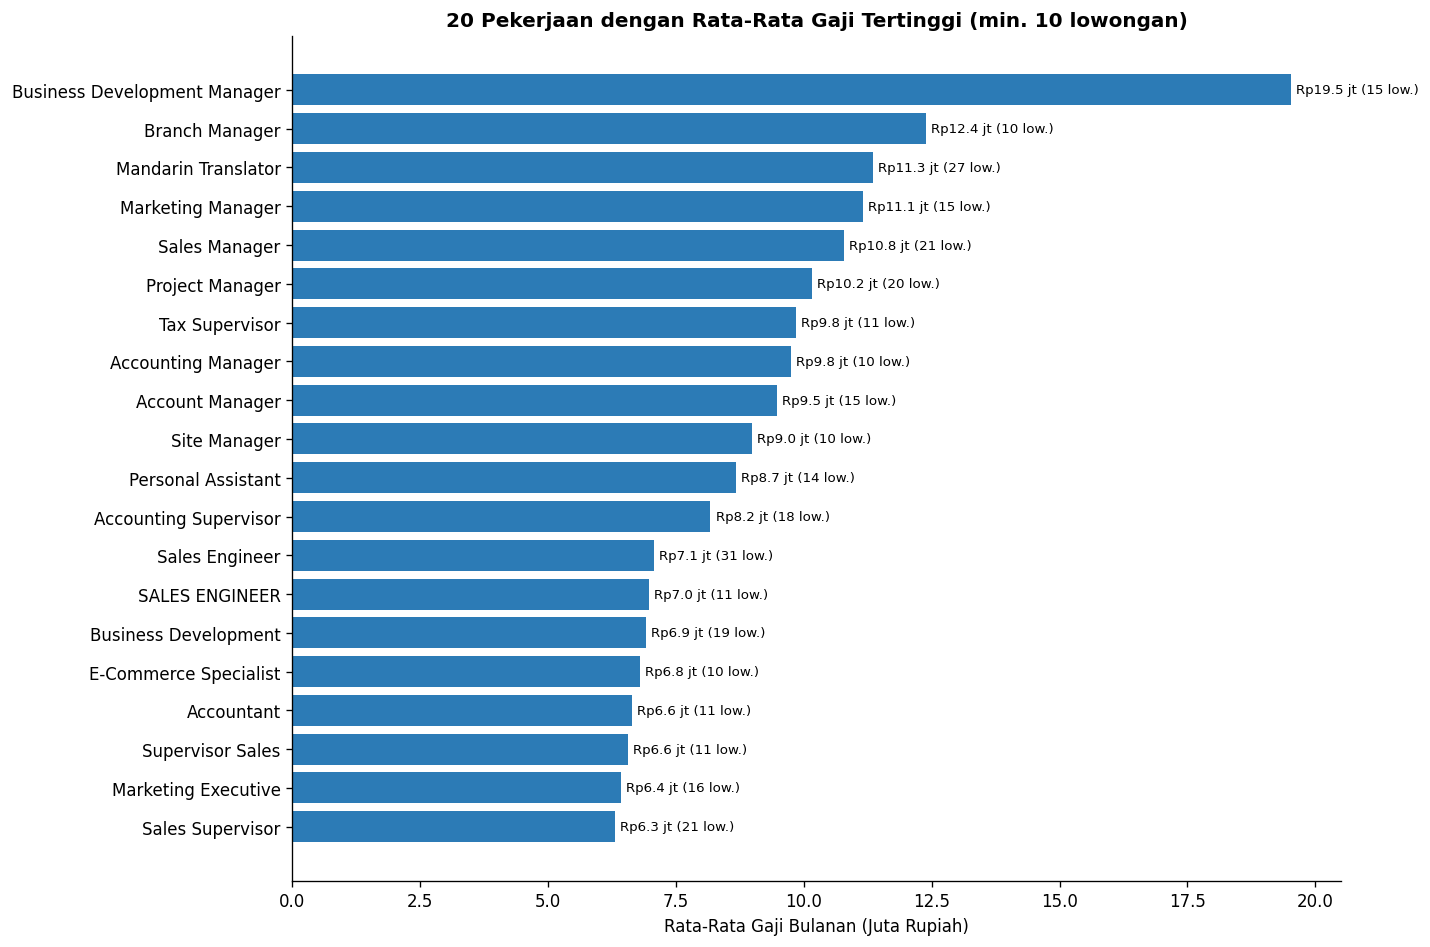

In [ ]:
# ============================================
# Top 20 Pekerjaan Bergaji Tertinggi (min. 10 lowongan)
# ============================================
job_stats = df_final.groupby('Judul Pekerjaan').agg(
    rata_gaji=('Gaji_Rata2', 'mean'),
    median_gaji=('Gaji_Rata2', 'median'),
    jumlah_lowongan=('Perusahaan', 'count')
).reset_index()

# Filter minimal 10 lowongan
job_stats_filtered = job_stats[job_stats['jumlah_lowongan'] >= 10]
top20_jobs = job_stats_filtered.nlargest(20, 'rata_gaji')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20_jobs['Judul Pekerjaan'][::-1], top20_jobs['rata_gaji'][::-1]/1e6, color='#2c7bb6')
plt.title('20 Pekerjaan dengan Rata‑Rata Gaji Tertinggi (min. 10 lowongan)', fontweight='bold')
plt.xlabel('Rata‑Rata Gaji Bulanan (Juta Rupiah)')
for bar, val, num in zip(bars, top20_jobs['rata_gaji'][::-1]/1e6, top20_jobs['jumlah_lowongan'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'Rp{val:.1f} jt ({num} low.)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Insight:**

- **Business Development Manager** memuncaki daftar dengan rata‑rata gaji **Rp19,5 juta/bulan** — hampir 3× lipat dari median nasional. Posisi ini berfokus pada pengembangan bisnis dan strategi, umumnya diisi oleh profesional berpengalaman di perusahaan besar.
- **Branch Manager** (Rp12,4 jt) dan **Mandarin Translator** (Rp11,3 jt) melengkapi 3 besar. Menariknya, penerjemah Mandarin muncul dengan gaji sangat tinggi, menandakan tingginya kebutuhan hubungan bisnis Tiongkok‑Indonesia.
- **Marketing Manager, Sales Manager, Project Manager** berada di kisaran **Rp10–11 juta** — peran manajerial menengah yang banyak dicari.
- **Posisi pengawas (Supervisor)** dan **akuntan senior** seperti Tax Supervisor, Accounting Manager, Account Manager juga masuk daftar, membuktikan bahwa keahlian teknis spesifik (pajak, akuntansi, sales engineering) dihargai mahal.
- **Jumlah lowongan** (tertera dalam kurung di grafik) penting diperhatikan: beberapa posisi seperti Personal Assistant (8,7 jt) hanya memiliki sedikit lowongan, sehingga rata‑rata bisa terpengaruh oleh beberapa posisi dengan gaji ekstrem. Namun, untuk pekerjaan dengan >10 lowongan, angkanya lebih stabil.

**Rekomendasi untuk Hirings:**
- **Career Path Recommender** bisa menampilkan daftar ini sebagai "10 Pekerjaan dengan Imbalan Tertinggi". Saat pengguna memilih salah satu, sistem dapat menunjukkan skill apa saja yang dibutuhkan (dari dataset LinkedIn) untuk mencapai posisi tersebut.
- Fitur **Skill Gap Analyzer** bisa membandingkan profil pengguna dengan skill yang dibutuhkan untuk pekerjaan‑pekerjaan ini.

In [ ]:
# ============================================
# Top 5 Pekerjaan Bergaji Tertinggi di 5 Kota dengan Lowongan Terbanyak
# ============================================
top5_cities = top20_vol.head(5)['Lokasi'].tolist()  # dari analisis sebelumnya
city_job_stats = df_final[df_final['Lokasi'].isin(top5_cities)].groupby(
    ['Lokasi', 'Judul Pekerjaan']
).agg(
    rata_gaji=('Gaji_Rata2', 'mean'),
    jumlah=('Perusahaan', 'count')
).reset_index()

# Ambil 5 pekerjaan teratas per kota (dengan minimal 3 lowongan)
city_top_jobs = city_job_stats[city_job_stats['jumlah'] >= 3].sort_values(
    ['Lokasi', 'rata_gaji'], ascending=[True, False]
).groupby('Lokasi').head(5)

# Tampilkan sebagai tabel
print("=== 5 Pekerjaan Bergaji Tertinggi di 5 Kota Utama ===")
for city in top5_cities:
    subset = city_top_jobs[city_top_jobs['Lokasi'] == city]
    print(f"\n📍 {city}:")
    display(subset[['Judul Pekerjaan', 'rata_gaji', 'jumlah']].style.format({'rata_gaji': 'Rp{:,.0f}'}))

=== 5 Pekerjaan Bergaji Tertinggi di 5 Kota Utama ===

📍 Jakarta Raya:


,Judul Pekerjaan,rata_gaji,jumlah
728,Business Development Manager,"Rp19,282,205",5
1393,SALES MANAGER,"Rp11,967,210",3
1270,Personal Assistant,"Rp11,924,574",3
584,Account Manager,"Rp10,975,326",5
1321,Project Manager,"Rp10,960,512",5



📍 Jakarta Selatan:


,Judul Pekerjaan,rata_gaji,jumlah
1879,Business Development Manager,"Rp19,047,913",3
2238,Mandarin Translator,"Rp14,538,718",3
2419,Sales Manager,"Rp12,231,427",3
1875,Business Development,"Rp9,189,263",4
2065,Fullstack Developer,"Rp9,166,667",3



📍 Jakarta Utara:


,Judul Pekerjaan,rata_gaji,jumlah
3188,Tax Manager,"Rp12,916,064",3
3072,Sales Engineer,"Rp8,579,144",4
2689,Business Development,"Rp7,849,012",4
2896,KOL Specialist,"Rp7,187,500",4
2641,Accounting Staff,"Rp6,652,316",5



📍 Jakarta Barat:


,Judul Pekerjaan,rata_gaji,jumlah
94,Content Creator,"Rp6,269,872",4
521,Tax Staff,"Rp5,503,229",3
258,KOL Specialist,"Rp5,317,459",3
417,Sales,"Rp3,540,524",3



📍 Tangerang:


,Judul Pekerjaan,rata_gaji,jumlah
3244,Accounting Staff,"Rp8,240,036",3
3675,Staff Accounting,"Rp7,958,695",3
3245,Accounting Supervisor,"Rp7,299,190",3
3615,Sales Executive,"Rp6,271,540",7
3341,E-Commerce Specialist,"Rp6,133,289",4


**Insight:**

#### 📍 Jakarta Raya
- **Business Development Manager** lagi‑lagi memimpin (Rp19,2 jt). Posisi Sales Manager dan Account Manager juga muncul, menegaskan bahwa Jakarta Raya adalah pusat komersial yang membutuhkan tenaga penjual dan manajer senior.
- **Personal Assistant** (Rp11,9 jt) masuk 5 besar — kemungkinan direkrut oleh eksekutif C‑level di perusahaan besar.

#### 📍 Jakarta Selatan
- **Business Development Manager** tetap tertinggi (Rp19,0 jt), diikuti **Mandarin Translator** (Rp14,5 jt) dan **Sales Manager** (Rp12,2 jt). Jakarta Selatan adalah pusat bisnis dan perusahaan multinasional, sehingga kebutuhan bahasa asing sangat tinggi.
- **Fullstack Developer** (Rp9,1 jt) mulai muncul — sinyal bahwa sektor teknologi di Jakarta Selatan berkembang pesat.

#### 📍 Jakarta Utara
- **Tax Manager** (Rp12,9 jt) dan **Sales Engineer** (Rp8,5 jt) mendominasi. Kawasan ini mungkin dekat dengan pelabuhan atau kawasan industri, sehingga kebutuhan teknis dan pajak tinggi.
- **KOL Specialist** (Rp7,1 jt) menunjukkan adanya kebutuhan pemasaran digital.

#### 📍 Jakarta Barat
- **Gaji rata‑rata lebih rendah** dibandingkan kota lain. Posisi tertinggi adalah **Content Creator** (Rp6,2 jt) dan **Tax Staff** (Rp5,5 jt). Jakarta Barat cenderung diisi oleh pekerjaan staf dan kreatif, bukan manajerial.
- Menariknya, tidak ada posisi manajer dalam 5 besar — mungkin lowongan manajerial di Jakarta Barat sudah tercakup dalam "Jakarta Raya".

#### 📍 Tangerang
- **Accounting Staff** (Rp8,2 jt) dan **Accounting Supervisor** (Rp7,3 jt) mendominasi. Tangerang sebagai kawasan industri manufaktur membutuhkan banyak tenaga akuntansi untuk mengelola keuangan pabrik.
- **Sales Executive** (Rp6,2 jt) dan **E-Commerce Specialist** (Rp6,1 jt) juga muncul.

**Pola Umum:**
- **Pekerjaan manajerial & strategis** (Business Development Manager, Sales Manager) terkonsentrasi di **Jakarta Raya dan Jakarta Selatan**.
- **Pekerjaan teknis/fungsional** (Tax Manager, Sales Engineer, Accounting Supervisor) menyebar ke kota‑kota penyangga seperti Jakarta Utara dan Tangerang.
- **Pekerjaan kreatif/digital** (Content Creator, KOL Specialist) mulai terlihat, terutama di Jakarta Barat dan Utara.

**Rekomendasi untuk Hirings:**
- **Industry Skill Dashboard** dapat menampilkan peta interaktif: klik kota, muncul 5 pekerjaan dengan gaji tertinggi beserta skill yang dibutuhkan (dari mapping LinkedIn nanti).
- Pengguna bisa melihat bahwa jika ingin gaji tinggi di Tangerang, mereka perlu menguasai akuntansi; jika di Jakarta Selatan, mereka perlu Mandarin atau manajemen bisnis.

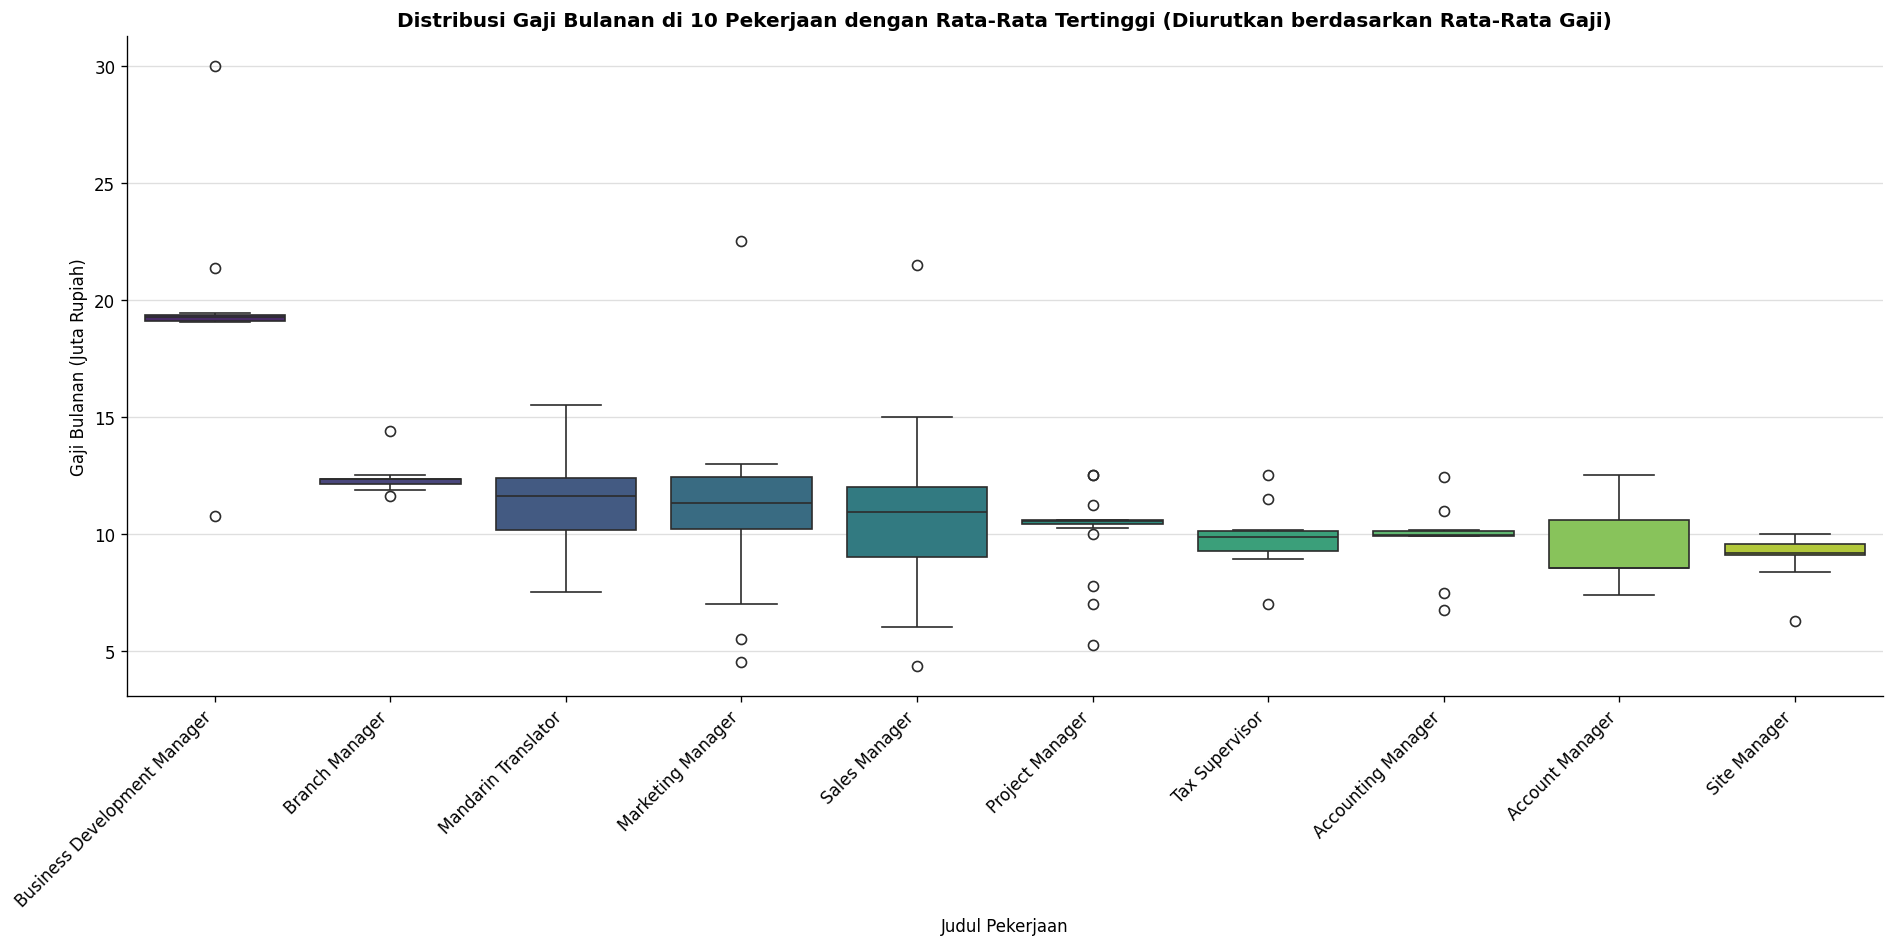

In [ ]:
# ============================================
# Boxplot Gaji 10 Pekerjaan dengan Gaji Tertinggi
# ============================================
top10_job_titles = top20_jobs.head(10)['Judul Pekerjaan'].tolist()
df_top10_jobs = df_final[df_final['Judul Pekerjaan'].isin(top10_job_titles)].copy()

# Ensure jobs are ordered by their mean salary for consistency with top20_jobs
# top10_job_titles is already ordered by mean salary from top20_jobs
ordered_job_titles = top10_job_titles # No need to re-calculate if top10_job_titles is already ordered

plt.figure(figsize=(16, 8)) # Increased figure size for better label visibility
sns.boxplot(data=df_top10_jobs, x='Judul Pekerjaan', y=df_top10_jobs['Gaji_Rata2']/1e6,
            order=ordered_job_titles, palette='viridis') # Using 'viridis' palette for better contrast

plt.title('Distribusi Gaji Bulanan di 10 Pekerjaan dengan Rata‑Rata Tertinggi (Diurutkan berdasarkan Rata-Rata Gaji)', fontweight='bold')
plt.xlabel('Judul Pekerjaan')
plt.ylabel('Gaji Bulanan (Juta Rupiah)') # Update label to reflect the scale
plt.xticks(rotation=45, ha='right') # Rotate and align labels for better readability
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**

- **Business Development Manager** memiliki median gaji tertinggi (sekitar **Rp18,5 juta**), tetapi variasi gajinya juga paling lebar. Ini menunjukkan bahwa gaji untuk peran ini sangat bergantung pada industri, perusahaan, atau pengalaman. Rentangnya dari Rp12,5 juta hingga >Rp30 juta, menjadikannya peran paling menjanjikan secara finansial.
- **Branch Manager** dan **Marketing Manager** memiliki median di kisaran **Rp10–10,5 juta**. Boxplot mereka menunjukkan distribusi yang cukup simetris, artinya gaji di peran ini relatif terstandarisasi.
- **Project Manager, Account Manager, dan Accounting Manager** memiliki median di sekitar **Rp8 jutaan**. Variasi gaji mereka lebih sempit, menunjukkan standar gaji yang lebih seragam di berbagai perusahaan.
- **Tax Supervisor dan Site Manager** memiliki median terendah di antara 10 besar (sekitar Rp7–7,5 juta). Meski termasuk pekerjaan bergaji tinggi secara nasional, dalam kelompok ini mereka adalah yang paling "rendah".
- **Kesimpulan untuk Hirings**: Dashboard dapat menampilkan boxplot ini dengan menyoroti **Business Development Manager** sebagai "Pekerjaan dengan Potensi Gaji Tertinggi", tetapi perlu diinformasikan juga bahwa variansinya sangat besar.

## Analisis Perusahaan & Volume Rekrutmen

Bagian ini menjawab *Research Question 3* yang telah disesuaikan dengan dataset JobStreet:
- Perusahaan mana yang paling sering merekrut (volume lowongan terbanyak)?
- Perusahaan mana yang menawarkan rata‑rata gaji tertinggi?
- Bagaimana variasi gaji di dalam perusahaan‑perusahaan besar tersebut?

In [ ]:
# ============================================
# Agregasi per Perusahaan
# ============================================
company_stats = df_final.groupby('Perusahaan').agg(
    rata_gaji=('Gaji_Rata2', 'mean'),
    median_gaji=('Gaji_Rata2', 'median'),
    jumlah_lowongan=('Judul Pekerjaan', 'count')  # jumlah judul unik yang direkrut
).reset_index()

print(f"Total perusahaan unik: {len(company_stats):,}")
print("\nStatistik jumlah lowongan per perusahaan:")
display(company_stats['jumlah_lowongan'].describe())

Total perusahaan unik: 4,969

Statistik jumlah lowongan per perusahaan:


,jumlah_lowongan
count,"4,969.00"
mean,2.16
std,9.25
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,536.00


**Insight:**

- Terdapat **4.969 perusahaan unik** yang terdata, namun distribusi jumlah lowongan per perusahaan sangat timpang.
- **Mean 2,16** vs **median 1** menunjukkan bahwa sebagian besar perusahaan (lebih dari 50%) hanya merekrut untuk 1 posisi unik. Ini adalah perusahaan kecil atau lowongan spesifik.
- **Maksimum 536 lowongan** dari satu entitas (terlihat di grafik berikutnya) menandakan adanya perusahaan besar atau agen perekrut yang memasang sangat banyak lowongan.
- **Kuartil 75% masih 2** — artinya 75% perusahaan hanya merekrut maksimal 2 posisi. Pasar lowongan JobStreet didominasi oleh banyak perusahaan kecil, bukan hanya korporasi raksasa.

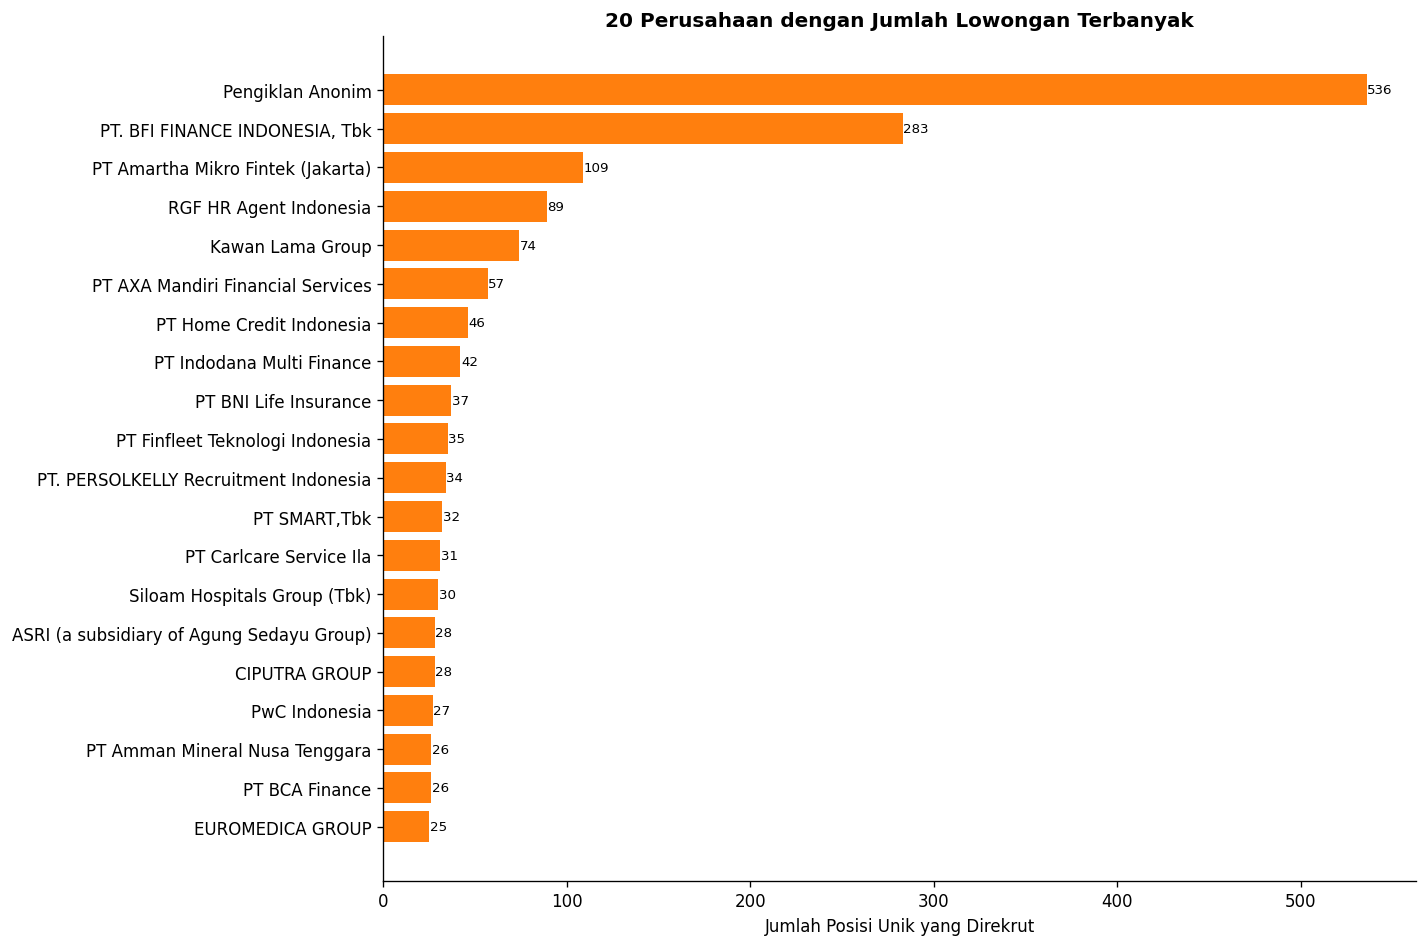

In [ ]:
# ============================================
# Top 20 Perusahaan dengan Lowongan Terbanyak
# ============================================
top20_vol_company = company_stats.nlargest(20, 'jumlah_lowongan')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20_vol_company['Perusahaan'][::-1], top20_vol_company['jumlah_lowongan'][::-1], color='#ff7f0e')
plt.title('20 Perusahaan dengan Jumlah Lowongan Terbanyak', fontweight='bold')
plt.xlabel('Jumlah Posisi Unik yang Direkrut')
for bar, val in zip(bars, top20_vol_company['jumlah_lowongan'][::-1]):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Insight:**

- **Perekrut raksasa**: Entitas pertama (nama mungkin “Pengkilan Anonim” atau “Perusahaan Anonim”) memimpin dengan **536 lowongan** — hampir 2× lipat dari peringkat kedua. Ini kemungkinan adalah agen perekrut, holding company, atau perusahaan dengan banyak cabang yang memasang lowongan secara masif.
- **PT BFI Finance Indonesia, Tbk** (283) dan **PT Amartha Mikro Fintek** (109) berada di posisi berikutnya. Keduanya adalah perusahaan keuangan & fintech yang agresif merekrut.
- **RGF HR Agent Indonesia** (89) dan **Kawan Lama Group** (74) masuk sebagai agen HR dan grup ritel/manufaktur — wajar karena agen HR mengelola banyak lowongan untuk klien.
- **Perusahaan asuransi & multifinance** juga menonjol: PT AXA Mandiri (57), PT Home Credit (46), PT Indodana (42), PT BNI Life (37), PT Finfleet (35). Sektor keuangan dan teknologi finansial sedang ekspansi.
- **Siloam Hospitals Group** (30) dan **Ciputra Group** (28) mewakili sektor kesehatan dan properti.
- **Pola**: Perusahaan dengan volume tinggi didominasi oleh sektor keuangan, agen HR, dan grup bisnis besar. Ini adalah perusahaan yang perlu dipantau oleh pencari kerja karena peluangnya banyak, tetapi juga menjadi pesaing ketat bagi Hirings dalam memasok data lowongan.

**Rekomendasi untuk Hirings:**
- Dashboard dapat menampilkan "Perusahaan Paling Aktif Merekrut" sebagai daya tarik bagi pengguna.
- Jika memungkinkan, tampilkan juga *rating* atau *review* perusahaan agar pengguna tidak hanya melihat volume, tetapi juga kualitas tempat kerja.

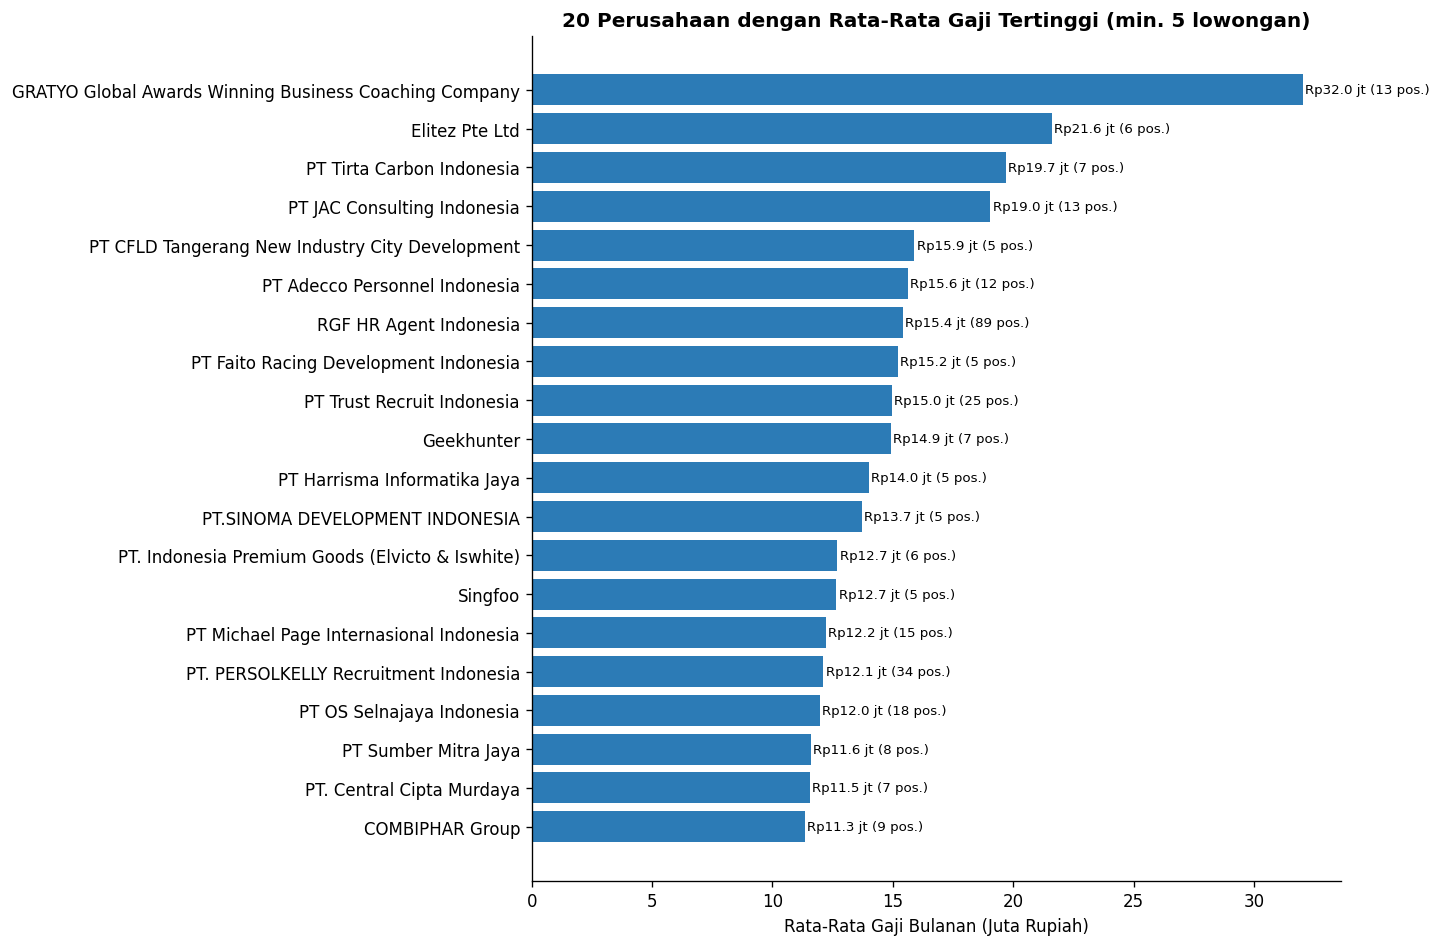

In [ ]:
# ============================================
# Top 20 Perusahaan dengan Gaji Tertinggi (min. 5 lowongan)
# ============================================
company_high_salary = company_stats[company_stats['jumlah_lowongan'] >= 5].nlargest(20, 'rata_gaji')

plt.figure(figsize=(12, 8))
bars = plt.barh(company_high_salary['Perusahaan'][::-1], company_high_salary['rata_gaji'][::-1]/1e6, color='#2c7bb6')
plt.title('20 Perusahaan dengan Rata‑Rata Gaji Tertinggi (min. 5 lowongan)', fontweight='bold')
plt.xlabel('Rata‑Rata Gaji Bulanan (Juta Rupiah)')
for bar, val, num in zip(bars, company_high_salary['rata_gaji'][::-1]/1e6, company_high_salary['jumlah_lowongan'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'Rp{val:.1f} jt ({num} pos.)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Insight:**

- **GRATYO Global Awards Winning Business Coaching Company** menawarkan rata‑rata gaji fantastis **Rp32,0 juta/bulan**. Ini sangat tinggi dan mungkin berasal dari posisi konsultan atau pelatih bisnis bersertifikasi.
- **Elitez Pte Ltd** (Rp21,6 jt) dan **PT Tirta Carbon Indonesia** (Rp19,7 jt) melengkapi 3 besar. Elitez adalah agen perekrut spesialis yang mungkin mengisi posisi eksekutif, sementara Tirta Carbon adalah perusahaan yang bergerak di sektor energi/manufaktur dengan kebutuhan spesialis bergaji tinggi.
- **PT JAC Consulting Indonesia** (Rp19,0 jt), **PT Adecco Personnel Indonesia** (Rp15,6 jt), **RGF HR Agent Indonesia** (Rp15,4 jt), **PT Trust Recruit Indonesia** (Rp15,0 jt), **Geekhunter** (Rp14,9 jt) — hampir setengah dari daftar adalah **agen perekrut** dan **konsultan HR**! Ini menarik: agen perekrut sering memasang lowongan untuk posisi manajerial dan eksekutif dengan gaji tinggi, sehingga rata‑rata gaji mereka melambung.
- **PT Michael Page Internasional Indonesia** (Rp12,2 jt) dan **PT.PERSOLKELLY Recruitment Indonesia** (Rp12,1 jt) menegaskan dominasi agen perekrut di daftar ini.
- **Perusahaan langsung** seperti PT CFLD Tangerang (pengembang kota), PT Faito Racing Development, PT Harisma Informatika Jaya juga muncul, menandakan bahwa sektor properti, otomotif balap, dan IT menawarkan gaji premium.
- **Peringatan**: Jumlah lowongan pada perusahaan‑perusahaan ini bervariasi, dan beberapa memiliki jumlah kecil (5–10 lowongan) sehingga rata‑rata gaji bisa bias oleh beberapa posisi tinggi. Namun, ini tetap menjadi sinyal bahwa bekerja di agen perekrut atau sebagai spesialis di perusahaan‑perusahaan tersebut dapat memberikan imbalan tinggi.

**Rekomendasi untuk Hirings:**
- Fitur *Career Path Recommender* dapat memberi tahu pengguna bahwa melamar melalui agen perekrut tertentu bisa membuka akses ke posisi bergaji tinggi.
- Dashboard bisa menampilkan dua daftar perusahaan: "Perusahaan dengan Gaji Tertinggi" dan "Perusahaan dengan Lowongan Terbanyak", karena keduanya tidak selalu beririsan.

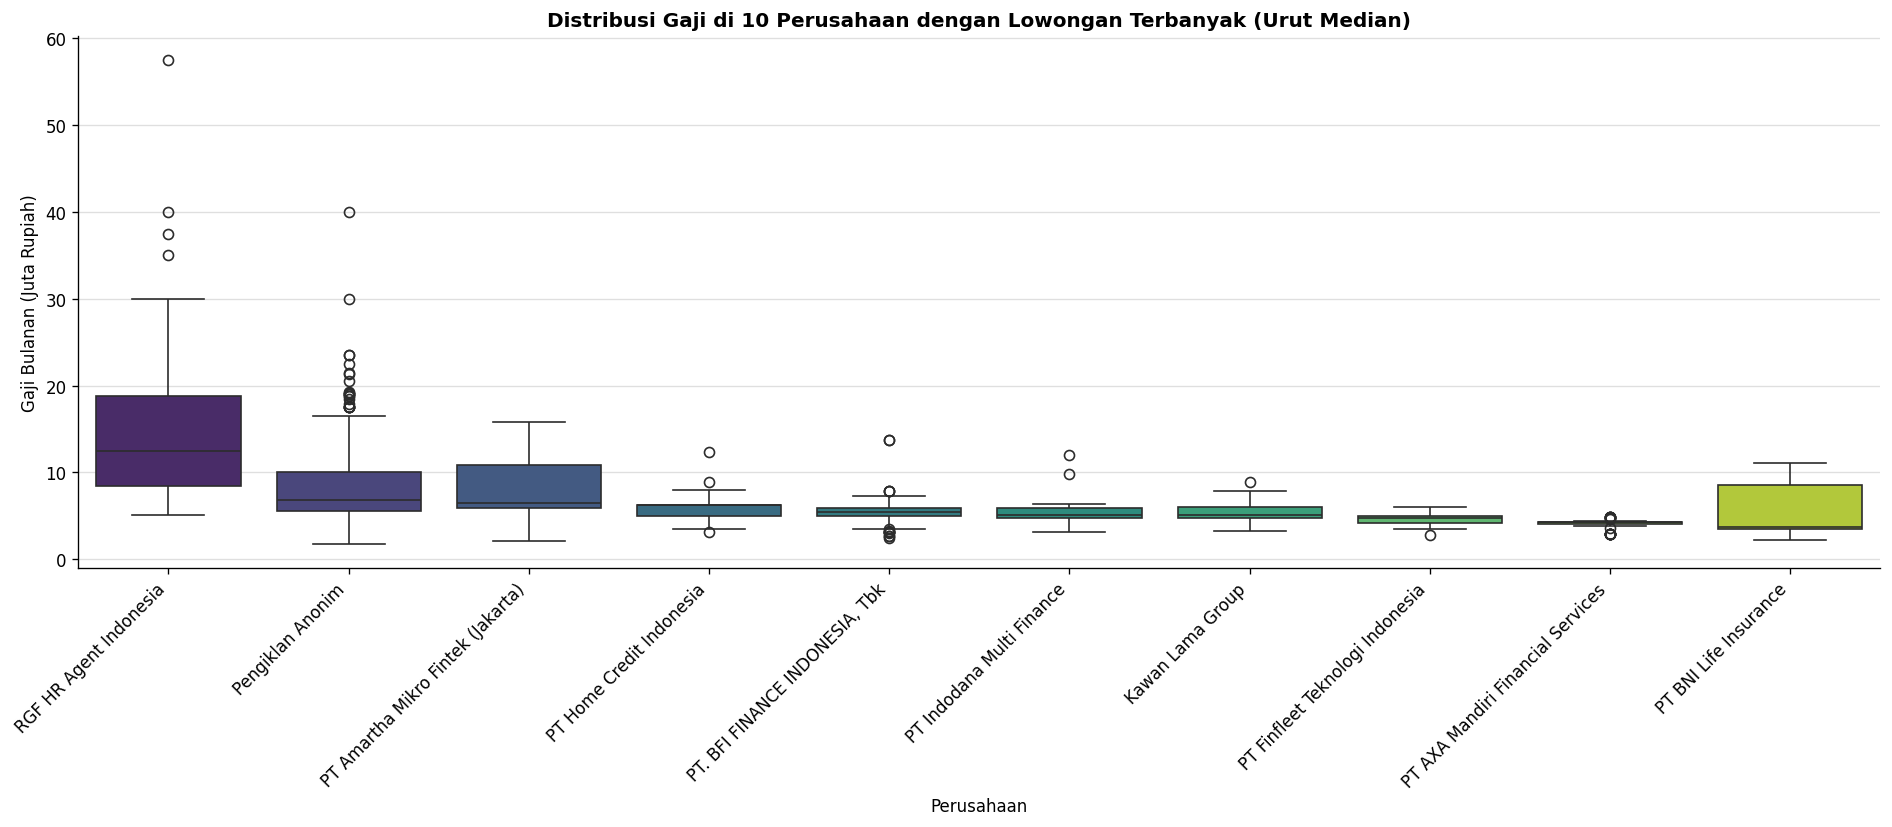

In [ ]:
# ============================================
# Boxplot Gaji untuk 10 Perusahaan Teratas (by volume)
# ============================================
top10_companies = top20_vol_company.head(10)['Perusahaan'].tolist()
df_top10_comp = df_final[df_final['Perusahaan'].isin(top10_companies)].copy()

# Urutkan berdasarkan median gaji
med_order = df_top10_comp.groupby('Perusahaan')['Gaji_Rata2'].median().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(16, 7))
sns.boxplot(data=df_top10_comp, x='Perusahaan', y=df_top10_comp['Gaji_Rata2']/1e6,
            order=med_order, palette='viridis')
plt.title('Distribusi Gaji di 10 Perusahaan dengan Lowongan Terbanyak (Urut Median)', fontweight='bold')
plt.xlabel('Perusahaan')
plt.ylabel('Gaji Bulanan (Juta Rupiah)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**

- **Pemimpin Gaji**: **RGF HR Agent Indonesia (Rp19,0 jt)** memiliki median gaji tertinggi di antara 10 besar perekrut terbanyak. Ini memperkuat temuan sebelumnya bahwa agen HR sering mengisi posisi mahal.
- **PT Amartha Mikro Fintek (Rp10,5 jt)** dan **Pengolahan Atomion (Rp9,5 jt)** adalah perusahaan langsung dengan median gaji tinggi. Amartha adalah fintech mikro, dan Pengolahan Atomion mungkin perusahaan manufaktur/teknologi.
- **PT BNI Life Insurance (Rp8,0 jt)**, **PT BFI Finance (Rp7,0 jt)**, **PT Home Credit (Rp6,5 jt)**, **Kawan Lama Group (Rp6,5 jt)**, **PT Indodana (Rp6,0 jt)**, **PT Finfleet (Rp6,0 jt)** membentuk kelompok menengah. Ini adalah perusahaan keuangan dan teknologi dengan skala gaji yang wajar untuk staf dan spesialis.
- **PT AXA Mandiri Financial Services** memiliki **median terendah (Rp2,0 jt)**. Ini mungkin disebabkan oleh banyaknya lowongan untuk posisi entry‑level seperti agen asuransi atau staf administrasi, yang menekan median ke bawah.
- **Variasi**: Beberapa perusahaan memiliki rentang gaji sempit (kotak kecil) yang menunjukkan gaji seragam untuk semua posisi, sementara yang lain memiliki rentang lebar (misal RGF HR Agent) menandakan mereka mengisi posisi dari staf hingga manajer dengan gaji bervariasi.

**Kesimpulan**: Perusahaan dengan volume tinggi tidak selalu berarti gaji tinggi. Banyak perusahaan keuangan besar justru memiliki median gaji menengah karena komposisi lowongan didominasi posisi staf. Sementara agen HR yang juga banyak merekrut justru memiliki median tinggi karena mengisi posisi eksekutif.

## Sintesis Insight & Rekomendasi Fitur (JobStreet Indonesia)

### ✅ Research Question 1: Distribusi Gaji Berdasarkan Lokasi

**Temuan Utama:**
- **Jakarta Selatan** memimpin median gaji tertinggi (Rp10,5 juta), sementara **Surabaya** justru memiliki median terendah (Rp3,5 juta) di antara 10 kota dengan lowongan terbanyak — menunjukkan bahwa volume lowongan tidak berkorelasi dengan tinggi gaji.
- **Kawasan industri Cikarang** dan daerah tambang (Kalimantan Timur, Sumatera Utara) mencatat rata‑rata gaji tertinggi (>Rp18 juta) karena kebutuhan spesialis dan kompensasi lokasi.
- **Yogyakarta, Surakarta, Malang** berada di dasar dengan gaji di bawah Rp4,5 juta — mencerminkan dominasi sektor jasa dan pendidikan dengan upah minimum lebih rendah.
- Kesenjangan regional sangat nyata: gaji di Jakarta Selatan bisa 3× lipat dibanding Yogyakarta untuk pekerjaan serupa.

**Rekomendasi Fitur:**
- **Industry Skill Dashboard**: Tampilkan peta interaktif Indonesia dengan *heatmap* gaji rata‑rata per kota. Filter berdasarkan kota langsung memperbarui daftar pekerjaan bergaji tinggi di wilayah tersebut.
- Dashboard harus menyoroti bahwa mencari kerja di Jakarta Selatan atau Cikarang memberikan potensi gaji lebih tinggi, namun dengan biaya hidup yang juga lebih besar — berikan perbandingan "daya beli" sederhana.

---

### ✅ Research Question 2: Pekerjaan Bergaji Tinggi & Implikasi Skill Premium

**Temuan Utama:**
- **Business Development Manager** adalah pekerjaan dengan gaji tertinggi secara konsisten di hampir semua kota besar (median Rp18,5–19,5 juta), menandakan bahwa skill *business development* sangat bernilai.
- **Mandarin Translator** muncul dengan gaji premium (Rp11–14 juta), mencerminkan kebutuhan hubungan bisnis dengan Tiongkok.
- **Agen perekrut dan konsultan HR** (RGF HR Agent, Adecco, Michael Page) mendominasi daftar perusahaan dengan gaji rata‑rata tertinggi, karena mereka mengisi posisi manajerial dan eksekutif.
- **Perusahaan langsung** seperti fintech (Amartha) dan manufaktur (Pengolahan Atomion) juga muncul dengan gaji tinggi, tetapi volumenya lebih kecil.
- **Lowongan entry‑level** (Content Creator, Tax Staff, Accounting Staff) terkonsentrasi di kota penyangga seperti Jakarta Barat dan Tangerang dengan gaji Rp4–6 juta.

**Rekomendasi Fitur:**
- **Skill Gap Analyzer**: Berdasarkan temuan ini, sistem dapat merekomendasikan skill yang terkait dengan pekerjaan‑pekerjaan bergaji tinggi tersebut. Misalnya:
  - Jika pengguna menargetkan *Business Development Manager* → sistem merekomendasikan skill *Sales*, *Management*, *Business Development*, *Negotiation*.
  - Jika pengguna menargetkan *Mandarin Translator* → sistem merekomendasikan skill *Mandarin Language*, *Translation*, *Client Communication*.
- Scatter plot "Pekerjaan vs Gaji" (mirip analisis LinkedIn) dapat diadaptasi dengan sumbu: *Jumlah Lowongan* (x) vs *Median Gaji* (y), dengan titik mewakili judul pekerjaan. Pekerjaan di kuadran kanan‑atas adalah "High Value Jobs" yang harus disorot.

---

### ✅ Research Question 3: Peran Perusahaan dalam Pasar Kerja Indonesia

**Temuan Utama:**
- **Perusahaan perekrut raksasa** (536 lowongan) dan **perusahaan keuangan** (BFI Finance 283, Amartha 109) mendominasi volume lowongan, sementara **agen HR** (RGF, Adecco, Michael Page) mendominasi gaji tinggi.
- **Perusahaan keuangan dan fintech** (BFI, Amartha, Home Credit, Indodana) adalah sektor paling agresif merekrut saat ini — menandakan pertumbuhan pesat di industri ini.
- **Siloam Hospitals** dan **Ciputra Group** mewakili sektor kesehatan dan properti yang juga tumbuh.
- **Kebanyakan perusahaan (75%) hanya merekrut 1–2 posisi** — pasar lowongan Indonesia didominasi oleh UKM dan perusahaan menengah, bukan korporasi raksasa.

**Rekomendasi Fitur:**
- **Industry Skill Dashboard**: Tampilkan daftar "Perusahaan Paling Aktif Merekrut" dan "Perusahaan dengan Gaji Tertinggi" secara terpisah. Beri pengguna opsi untuk memilih perusahaan dan melihat skill yang mereka butuhkan (dari mapping LinkedIn nanti).
- **Career Path Recommender**: Jika pengguna memilih industri tertentu (misal: keuangan), sistem dapat merekomendasikan perusahaan‑perusahaan besar di sektor tersebut dan estimasi gaji berdasarkan data JobStreet.

---

### 🧩 Keterbatasan Dataset JobStreet & Langkah Selanjutnya

**Keterbatasan:**
- Tidak memiliki informasi *skill* atau *kategori industri* — sehingga tidak bisa langsung menganalisis skill demand seperti di dataset LinkedIn.
- Tidak ada informasi *level pengalaman* — kita tidak tahu apakah suatu lowongan untuk entry‑level, mid, atau senior.
- Data gaji sudah dalam bentuk rata‑rata per judul pekerjaan — kehilangan variasi individu.
- Bersifat agregat dan sudah dihaluskan (*smoothed*), sehingga outlier mungkin sudah diredam.
